# Stability Consensus Analysis on EMOS CIF Dataset

This notebook runs `StabilityConsensusAnalysisFeature` on CIF files from the EMOS stability dataset and exports analysis outputs (JSON and CSV) into this analysis folder.

In [1]:
import csv
import json
import os
import sys
import time
from pathlib import Path

workspace_root = Path(os.path.abspath("")).resolve()
while workspace_root != workspace_root.parent:
    if (workspace_root / "Features").is_dir() and (workspace_root / "Information_Units").is_dir():
        break
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from Features.Materials_Exploration.StabilityConsensusAnalysis.StabilityConsensusAnalysisFeature import StabilityConsensusAnalysisFeature

analysis_root = workspace_root / "Features" / "Materials_Exploration" / "StabilityConsensusAnalysis" / "analysis"
analysis_root.mkdir(parents=True, exist_ok=True)

print(f"Workspace root: {workspace_root}")
print(f"Analysis output folder: {analysis_root}")

Workspace root: /mnt/c/Users/smishra2/Desktop/EMOS
Analysis output folder: /mnt/c/Users/smishra2/Desktop/EMOS/Features/Materials_Exploration/StabilityConsensusAnalysis/analysis


In [2]:
dataset_candidates = [
    workspace_root / "Features" / "Materials_Exploration" / "StabilityConsensusAnalysis" / "emos_cif_files" / "emos_stability_dataset",
    workspace_root / "Features" / "Materials_Exploration" / "StabilityConsensusAnalysis" / "emos_cif_files" / "emos_cif_files" / "emos_stability_dataset",
]

dataset_dir = next((path for path in dataset_candidates if path.is_dir()), None)
if dataset_dir is None:
    raise FileNotFoundError(
        "Could not find dataset directory. Checked: "
        + ", ".join(str(p) for p in dataset_candidates)
    )

cif_paths = sorted(dataset_dir.glob("*.cif"))
if not cif_paths:
    raise FileNotFoundError(f"No CIF files found in: {dataset_dir}")

print(f"Dataset folder: {dataset_dir}")
print(f"Number of CIF files found: {len(cif_paths)}")
print("Sample files:")
for p in cif_paths[:10]:
    print(f"  - {p.name}")

Dataset folder: /mnt/c/Users/smishra2/Desktop/EMOS/Features/Materials_Exploration/StabilityConsensusAnalysis/emos_cif_files/emos_cif_files/emos_stability_dataset
Number of CIF files found: 53
Sample files:
  - AcDy3 (1).cif
  - AcDy3.cif
  - AcEr3.cif
  - Ba3As2.cif
  - Ba3AsN.cif
  - Ba3AsP.cif
  - CsHo3.cif
  - Eu3Dy.cif
  - Eu3Ho.cif
  - Eu3Mg.cif


In [3]:
def load_cif_entries(paths, max_files=None):
    selected_paths = paths if max_files is None else paths[:max_files]
    entries = []
    for path in selected_paths:
        entries.append({
            "name": path.name,
            "content": path.read_text(encoding="utf-8", errors="ignore"),
        })
    return entries

MAX_FILES = None
cif_entries = load_cif_entries(cif_paths, max_files=MAX_FILES)
print(f"Prepared CIF entries for analysis: {len(cif_entries)}")

Prepared CIF entries for analysis: 53


In [4]:
ACTIVE_DATABASES = [
    {"value": "materialsproject", "name": "Materials Project"},
    {"value": "alexandria", "name": "Alexandria"},
]

# Keep predictor calls optional in case runtime dependencies/services are unavailable.
USE_PREDICTORS = True
ACTIVE_PREDICTORS = [
    {"value": "mattersim", "name": "MatterSim"},
    {"value": "chgnet", "name": "CHGNet"},
] if USE_PREDICTORS else []

payload = {
    "cif_files": cif_entries,
    "active_databases": ACTIVE_DATABASES,
    "active_predictors": ACTIVE_PREDICTORS,
}

print("Configured payload:")
print(f"  CIF files: {len(payload['cif_files'])}")
print(f"  Databases: {[d['value'] for d in payload['active_databases']]}")
print(f"  Predictors: {[p['value'] for p in payload['active_predictors']]}")

Configured payload:
  CIF files: 53
  Databases: ['materialsproject', 'alexandria']
  Predictors: ['mattersim', 'chgnet']


In [5]:
feature = StabilityConsensusAnalysisFeature()
inputs = feature.extract_inputs(payload)

started = time.time()
raw_results = feature.process_feature(inputs)
elapsed_seconds = round(time.time() - started, 2)

formatted_results = feature.format_outputs(raw_results)
results_per_cif = formatted_results.get("results_per_cif", [])
batch_summary = formatted_results.get("batch_summary", {})
plot_data = formatted_results.get("plot_data", {})

print(f"Feature runtime (s): {elapsed_seconds}")
print("Batch summary:")
print(json.dumps(batch_summary, indent=2))
print(f"Results entries returned: {len(results_per_cif)}")

/home/smishra2/miniforge3/envs/mattersim/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/smishra2/miniforge3/envs/mattersim/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


Feature runtime (s): 4790.37
Batch summary:
{
  "total_files": 53,
  "processed_files": 53,
  "failed_files": 0,
  "stable_votes": 128,
  "unstable_votes": 60
}
Results entries returned: 53


In [6]:
def parse_stability_label(label):
    if not isinstance(label, str):
        return "unknown"
    lowered = label.lower()
    if "unstable" in lowered:
        return "unstable"
    if "stable" in lowered:
        return "stable"
    if "not found" in lowered:
        return "not_found"
    return "other"

summary_rows = []
source_rows = []

for result in results_per_cif:
    cif_name = result.get("cif_name", "")
    error_text = result.get("error", "")
    summary = result.get("summary", {}) or {}

    summary_rows.append({
        "cif_name": cif_name,
        "composition": result.get("composition", ""),
        "space_group_number": result.get("space_group_number", ""),
        "space_group_symbol": result.get("space_group_symbol", ""),
        "materialsproject_id": result.get("materialsproject_id", ""),
        "stable_count": summary.get("stable_count", 0),
        "unstable_count": summary.get("unstable_count", 0),
        "total_sources": summary.get("total_sources", 0),
        "consensus": summary.get("consensus", ""),
        "error": error_text,
    })

    for source_name, source_data in (result.get("sources", {}) or {}).items():
        label = source_data.get("stability") if isinstance(source_data, dict) else None
        source_rows.append({
            "cif_name": cif_name,
            "composition": result.get("composition", ""),
            "source": source_name,
            "status": source_data.get("status") if isinstance(source_data, dict) else None,
            "stability": label,
            "stability_class": parse_stability_label(label),
            "raw_value": source_data.get("raw_value") if isinstance(source_data, dict) else None,
            "threshold": source_data.get("threshold") if isinstance(source_data, dict) else None,
            "unit": source_data.get("unit") if isinstance(source_data, dict) else None,
            "description": source_data.get("description") if isinstance(source_data, dict) else None,
            "message": source_data.get("message") if isinstance(source_data, dict) else None,
        })

print(f"Summary rows: {len(summary_rows)}")
print(f"Per-source rows: {len(source_rows)}")

Summary rows: 53
Per-source rows: 212


In [7]:
json_path = analysis_root / "stability_consensus_results.json"
summary_csv_path = analysis_root / "stability_consensus_summary.csv"
source_csv_path = analysis_root / "stability_consensus_source_details.csv"

json_payload = None
if formatted_results.get("downloadResultsJson"):
    try:
        json_payload = json.loads(formatted_results["downloadResultsJson"])
    except Exception:
        json_payload = raw_results
else:
    json_payload = raw_results

json_path.write_text(json.dumps(json_payload, indent=2), encoding="utf-8")

summary_fields = [
    "cif_name",
    "composition",
    "space_group_number",
    "space_group_symbol",
    "materialsproject_id",
    "stable_count",
    "unstable_count",
    "total_sources",
    "consensus",
    "error",
]
with summary_csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=summary_fields, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(summary_rows)

source_fields = [
    "cif_name",
    "composition",
    "source",
    "status",
    "stability",
    "stability_class",
    "raw_value",
    "threshold",
    "unit",
    "description",
    "message",
]
with source_csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=source_fields, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(source_rows)

print(f"Saved JSON report: {json_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved source-details CSV: {source_csv_path}")

Saved JSON report: /mnt/c/Users/smishra2/Desktop/EMOS/Features/Materials_Exploration/StabilityConsensusAnalysis/analysis/stability_consensus_results.json
Saved summary CSV: /mnt/c/Users/smishra2/Desktop/EMOS/Features/Materials_Exploration/StabilityConsensusAnalysis/analysis/stability_consensus_summary.csv
Saved source-details CSV: /mnt/c/Users/smishra2/Desktop/EMOS/Features/Materials_Exploration/StabilityConsensusAnalysis/analysis/stability_consensus_source_details.csv


In [8]:
try:
    import pandas as pd

    summary_df = pd.DataFrame(summary_rows)
    source_df = pd.DataFrame(source_rows)

    print("Per-CIF summary (first 15 rows):")
    display(summary_df.head(15))

    print("Per-source stability distribution:")
    if not source_df.empty:
        display(source_df.groupby(["source", "stability_class"]).size().reset_index(name="count"))
    else:
        print("No source rows available.")

    print("Batch summary from feature:")
    display(pd.DataFrame([batch_summary]))

    print("Plot data from feature:")
    display(pd.DataFrame.from_dict(plot_data, orient="index").reset_index().rename(columns={"index": "source"}))
except Exception as exc:
    print("Pandas not available or display failed.")
    print(f"Reason: {exc}")
    print("Batch summary:")
    print(json.dumps(batch_summary, indent=2))

Per-CIF summary (first 15 rows):


,cif_name,composition,space_group_number,space_group_symbol,materialsproject_id,stable_count,unstable_count,total_sources,consensus,error
0,AcDy3 (1).cif,AcDy3,139,I4/mmm,None,0,3,4,❌ All sources agree: Unstable,
1,AcDy3.cif,AcDy3,221,Pm-3m,None,0,3,4,❌ All sources agree: Unstable,
2,AcEr3.cif,AcEr3,221,Pm-3m,None,0,4,4,❌ All sources agree: Unstable,
3,Ba3As2.cif,Ba3As2,221,Pm-3m,None,0,3,4,❌ All sources agree: Unstable,
4,Ba3AsN.cif,Ba3AsN,221,Pm-3m,None,0,3,4,❌ All sources agree: Unstable,
5,Ba3AsP.cif,Ba3AsP,221,Pm-3m,None,0,3,4,❌ All sources agree: Unstable,
6,CsHo3.cif,CsHo3,221,Pm-3m,None,0,3,4,❌ All sources agree: Unstable,
7,Eu3Dy.cif,Eu3Dy,194,P6_3/mmc,None,2,1,4,"⚠️ Mixed opinion: 2 stable, 1 unstable",
8,Eu3Ho.cif,Eu3Ho,194,P6_3/mmc,None,2,1,4,"⚠️ Mixed opinion: 2 stable, 1 unstable",
9,Eu3Mg.cif,Eu3Mg,221,Pm-3m,None,3,1,4,"⚠️ Mixed opinion: 3 stable, 1 unstable",


Per-source stability distribution:


,source,stability_class,count
0,alexandria,not_found,19
1,alexandria,stable,27
2,alexandria,unknown,4
3,alexandria,unstable,3
4,chgnet,stable,37
5,chgnet,unstable,16
6,materialsproject,stable,26
7,materialsproject,unknown,1
8,materialsproject,unstable,26
9,mattersim,stable,38


Batch summary from feature:


,total_files,processed_files,failed_files,stable_votes,unstable_votes
0,53,53,0,128,60


Plot data from feature:


,source,stable_count,unstable_count,error_count,total,stable_pct,unstable_pct,error_pct
0,materialsproject,26,26,0,52,50.0,50.0,0.0
1,alexandria,27,3,19,49,55.1,6.1,38.8
2,chgnet,37,16,0,53,69.8,30.2,0.0
3,mattersim,38,15,0,53,71.7,28.3,0.0


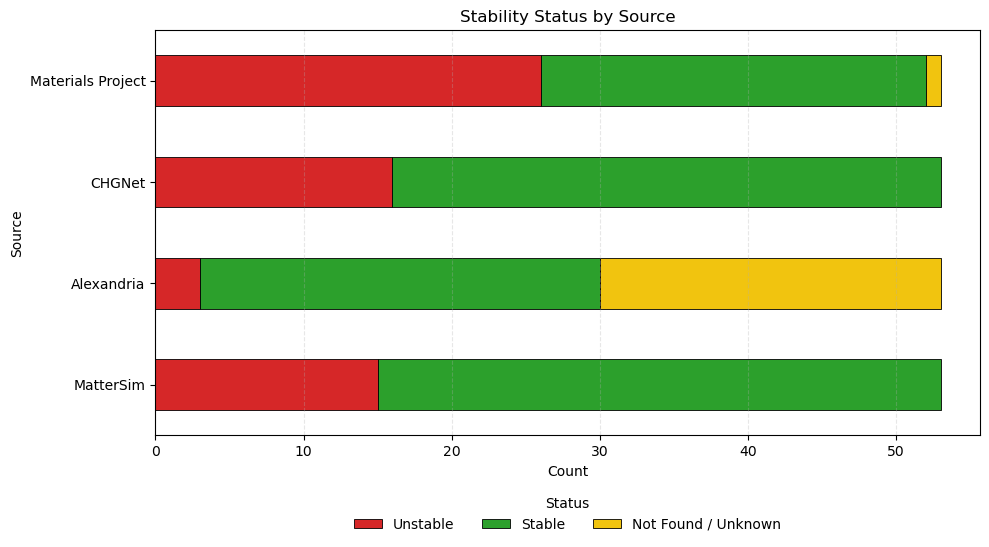

Counts used for plotting:


status_bucket,source,unstable,stable,unknown_or_not_found
0,mattersim,15,38,0
1,alexandria,3,27,23
2,chgnet,16,37,0
3,materialsproject,26,26,1


In [11]:
# Plot per-source stability status distribution with fixed colors.
import pandas as pd
import matplotlib.pyplot as plt

if 'source_rows' not in globals() or not source_rows:
    raise ValueError("source_rows is empty. Run previous analysis cells first.")

plot_df = pd.DataFrame(source_rows)
if plot_df.empty:
    raise ValueError("No source-level rows available to plot.")

# Normalize labels to the three buckets requested.
def normalize_status(value):
    v = str(value).strip().lower()
    if v == "stable":
        return "stable"
    if v == "unstable":
        return "unstable"
    return "unknown_or_not_found"

plot_df["status_bucket"] = plot_df["stability_class"].map(normalize_status)

# Count each bucket per source and ensure all expected sources/categories are shown.
source_order = ["mattersim", "alexandria", "chgnet", "materialsproject"]
bucket_order = ["unstable", "stable", "unknown_or_not_found"]

counts = (
    plot_df.groupby(["source", "status_bucket"]).size().unstack(fill_value=0)
    .reindex(index=source_order, fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)

colors = {
    "unstable": "#d62728",            # red
    "stable": "#2ca02c",              # green
    "unknown_or_not_found": "#f1c40f" # yellow
}

ax = counts.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    color=[colors[c] for c in bucket_order],
    edgecolor="black",
    linewidth=0.6,
)

ax.set_title("Stability Status by Source")
ax.set_xlabel("Count")
ax.set_ylabel("Source")
ax.set_yticklabels(["MatterSim", "Alexandria", "CHGNet", "Materials Project"], rotation=0)
ax.legend(
    ["Unstable", "Stable", "Not Found / Unknown"],
    title="Status",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
)
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print("Counts used for plotting:")
display(counts.reset_index().rename(columns={"index": "source"}))